In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/industrial-ai-project/data/processed/metropt3_features.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

split_date = pd.to_datetime("2020-06-08 00:00:00")
train_df = df[df['timestamp'] < split_date]
test_df = df[df['timestamp'] >= split_date]

feature_cols = [
    'TP2_rolling_mean', 'TP2_rolling_max', 'TP2_rolling_std',
    'H1_rolling_mean', 'H1_rolling_max', 'H1_rolling_std',
    'Oil_temperature_rolling_mean', 'Oil_temperature_rolling_max', 'Oil_temperature_rolling_std',
    'Motor_current_rolling_mean', 'Motor_current_rolling_max', 'Motor_current_rolling_std'
]

X_train = train_df[feature_cols]

print("Train shape:", X_train.shape)

Train shape: (150265, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

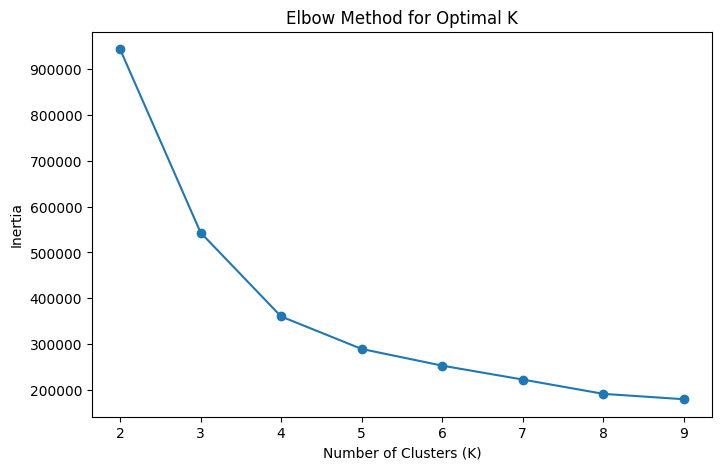

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [ ]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
train_df = train_df.copy()
train_df['cluster'] = kmeans_final.fit_predict(X_train_scaled)

print(train_df['cluster'].value_counts())

cluster
1    69299
0    38593
2    31774
3    10599
Name: count, dtype: int64


In [ ]:
# Calculate the average sensor values for each cluster
cluster_summary = train_df.groupby('cluster')[feature_cols].mean()
print(cluster_summary)

         TP2_rolling_mean  TP2_rolling_max  TP2_rolling_std  H1_rolling_mean  \
cluster                                                                        
0                0.061486         0.354812         0.164499         9.347418   
1                0.003859         0.070935         0.037676         8.662279   
2                3.365320         9.244748         4.263331         5.681050   
3                8.304453         8.420434         0.107777         0.001189   

         H1_rolling_max  H1_rolling_std  Oil_temperature_rolling_mean  \
cluster                                                                 
0              9.619914        0.302413                     63.527720   
1              8.810617        0.146623                     56.617653   
2              9.254768        4.171785                     60.921218   
3              0.033462        0.018965                     74.408198   

         Oil_temperature_rolling_max  Oil_temperature_rolling_std  \
cluster    

In [ ]:
# Check failure rate within each cluster
train_df['is_failure'] = train_df['is_failure']  # already exists
cluster_failure_rate = train_df.groupby('cluster')['is_failure'].mean()
print(cluster_failure_rate)

cluster
0    0.000000
1    0.000274
2    0.000126
3    0.439192
Name: is_failure, dtype: float64


## Key Finding: Cluster 3 Strongly Associated with Failures

K-Means (K=4, chosen via elbow method) identified 4 distinct operating
states, discovered purely from sensor patterns (no failure labels used
in training):

- Cluster 0 (Idle/Standby): 0% failure rate
- Cluster 1 (Full Rest): 0.03% failure rate  
- Cluster 2 (Active/Transitional): 0.01% failure rate
- Cluster 3 (Full Load - high pressure, high temperature, zero H1):
  43.9% failure rate

This is a striking result: an unsupervised method independently
rediscovered the failure-associated pattern found in EDA (high TP2,
high oil temperature, silent H1), without ever seeing failure labels.

Potential application: cluster membership (is_full_load_cluster) could
be added as a feature to the classification model.

In [ ]:
# Apply the trained K-Means model to BOTH train and test sets
test_df = test_df.copy()

X_test_scaled = scaler.transform(test_df[feature_cols])
test_df['cluster'] = kmeans_final.predict(X_test_scaled)

# Create a simple binary feature: is this row in the "Full Load" cluster (3)?
train_df['is_full_load_cluster'] = (train_df['cluster'] == 3).astype(int)
test_df['is_full_load_cluster'] = (test_df['cluster'] == 3).astype(int)

print("Train:", train_df['is_full_load_cluster'].value_counts())
print("Test:", test_df['is_full_load_cluster'].value_counts())

Train: is_full_load_cluster
0    139666
1     10599
Name: count, dtype: int64
Test: is_full_load_cluster
0    96791
1     4336
Name: count, dtype: int64


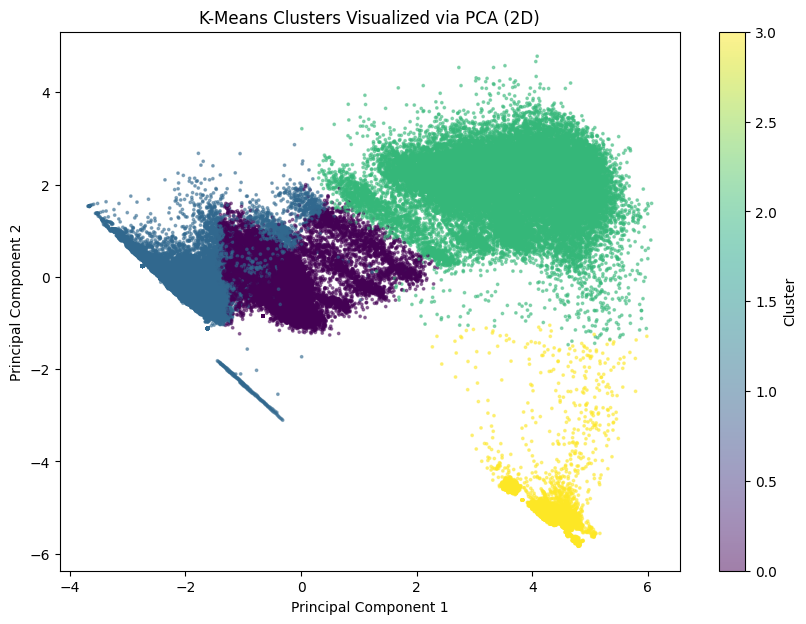

Variance explained by 2 components: 0.7834050712339425


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce the 12 features to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot each point colored by its cluster
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                       c=train_df['cluster'], cmap='viridis', s=3, alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters Visualized via PCA (2D)')
plt.show()

# How much information (variance) do the 2 components capture?
print("Variance explained by 2 components:", pca.explained_variance_ratio_.sum())